## Apresentação ✒️

Notebook destinado ao estudo da elaboração de um modelo que consiga classificar em função das features (caraterísticas) que se relacionam a um perfil do cliente classificar se um cliente qualquer irá realizar churn ou não churn. Churn é o termo em que se dá para pessoas que deixam de ser clientes de uma empresa, não passando mais consumir seus produtos oferecidos e, com isso, impactando negativamente na geração da receita da empresa. Um dos grandes problemas desse cenário é que ele pode engendrar não apenas uma perda do cliente que deixa de contribuir com os ganhos da empresa, mas também de outros em potencial a partir dele, gerando um certo efeito multiplicativo de perda : um cliente que deixa de consumir produtos da empresa pode falar para os seus pares fazerem o mesmo. 

Em virtude disso, uma frequente aplicação de modelos de machine learning no mercado se dá em razão de conseguir identificar quais são as features que denotam um cliente que pode realizar churn em potencial e identificá-los como forma de se precaverem e/ou elaborarem políticas que visam o arrefecimento desse tipo de desligamento. Como se trata de um contexto de classificação, para tanto será implementado os principais modelos de classificação disponíveis e depois irei comparar qual deles melhor performa para serem provisionados para a empresa. A métrica que servirá de limiar de decisão será a f1-score, com consideração complementar da matriz de confusão e ROC-AUC, uma vez que em tais cenários o uso da acurácia se torna contraproducente, dado que a frequência de churn (espera-se) é menor do que o não churn, representando um desbalanceamento nas label, portanto. Para entender melhor sobre essa cosnideração e demais métricas de modelos de machine learning, ler o artigo a seguir : [Métricas para modelos de ML](https://medium.com/@brunoloducca15/métricas-de-avaliação-para-machine-learning-249f16d104da) . 

- Dataset utilizado : [dataset utilizado](https://www.kaggle.com/code/emanuelcatao/creditcardfraud?select=card_transdata.csv).


### Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import math

import matplotlib.pyplot as plt
import optuna
import pandas as pd
import numpy as np
import seaborn as sns

from pandas import DataFrame
from scipy.stats.mstats import winsorize
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (auc, classification_report, confusion_matrix,
                             f1_score, make_scorer, precision_score,
                             recall_score, roc_curve)

from sklearn.model_selection import (StratifiedKFold, cross_validate, RandomizedSearchCV, 
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Carregando o dataset

In [31]:
df = pd.read_csv("card_transdata.csv")

df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [32]:
df.shape

(1000000, 8)

### Verificando a integridade do dataset

In [33]:
df.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


### Legenda das features relevantes

| **Feature**                        | **Tarefa**                                                                                       | **Objetivo/Descrição**                                                                                          |
|-----------------------------------|--------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------|
| `distance_from_home`              | Verifique se a transação ocorreu a uma distância incomum da residência do usuário.               | Distâncias atípicas podem indicar comportamento fraudulento.                                                    |
| `distance_from_last_transaction` | Avalie a diferença de localização entre a transação atual e a anterior.                         | Grandes deslocamentos em pouco tempo podem ser suspeitos.                                                       |
| `ratio_to_median_purchase_price` | Compare o valor da compra atual com a mediana dos gastos anteriores do cliente.                 | Um valor muito acima da mediana pode indicar uma transação fora do perfil.                                      |
| `repeat_retailer`                | Verifique se o comerciante é um estabelecimento já frequente para o cliente.                    | Compras em novos estabelecimentos podem levantar suspeitas.                                                     |
| `used_chip`                      | Identifique se o chip do cartão foi utilizado.                                                   | O uso do chip sugere maior segurança na transação presencial.                                                   |
| `used_pin_number`               | Determine se o número PIN foi exigido na transação.                                              | A ausência de PIN pode indicar uma transação menos segura, especialmente em compras presenciais.                |
| `online_order`                   | Avalie se a transação foi feita online.                                                          | Transações online tendem a ser mais vulneráveis a fraudes.                                                      |
| `fraud` (target)                 | Classificar a transação como fraudulenta ou legítima.                                            | Variável-alvo: 1 para fraude, 0 para transação legítima.                                                         |



### Featuring Engineering

In [8]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [9]:
df.shape

(1000000, 8)

### Análise de Dados

In [10]:
"""
O nível de churn está assimétrico entre si - o que é bom. 
Nesse sentido, adotar a acurácia para avaliar a performance dos modelos
de ML se torna contraproducente.  
"""

df.fraud.value_counts()

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

<Axes: >

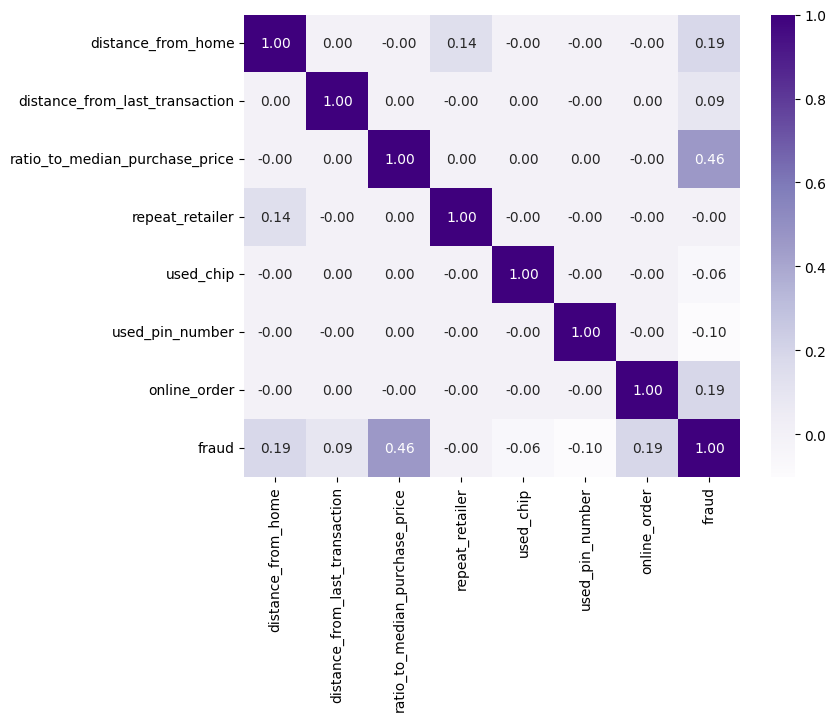

In [11]:
corr_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Purples", fmt=".2f")

Analisando a matriz de Pearson, pode-se perceber que existem algumas features que apresentam uma relação linear, tais como `ratio_to_median_purchase_price`, `distance_from_home`, `distance_from_last_transaction`, `online_order`, `used_pin_number`, as quais podem apresentar uma relação positiva e negativa, de modo que a primeira se refere a um cenário de features que contribuem com a ocorrência de fraude e, no segundo caso, que contribuem negativamente, isto é, de features que denotam a não ocorrência do evento. 

Nesse sentido, pode-se destacar por exemplo a feature `distance_from_home`, que se relaciona à distância longe da cada do usuário, de modo que quanto maior essa for, maior verifica-se a ocorrência de fraude, enquanto que a `used_pin_number` informa o oposto, tendo em vista que a sua presença está atrelada a compras mais seguras, sobretudo se presenciais. 

In [12]:
def boxplot(
          dataset: DataFrame, 
          style : str, 
          height : int, 
          width : int
      ):
      
      """ 
      Generates a series of boxplots for each feature in the provided dataset.

      This function uses Seaborn and Matplotlib to create boxplots for all columns in the dataset. 
      The visual style of the plots is set using the provided style parameter. The plots are arranged 
      in a grid layout with 2 rows and 3 columns, and the figure size is determined by the height and 
      width parameters.

      Args:
        dataset (DataFrame): The dataset containing the features to be visualized.
        style (str): The Seaborn style theme to be applied to the plots (e.g., "darkgrid", "whitegrid").
        height (int): The height of the overall figure.
        width (int): The width of the overall figure.

      Returns:
        None: This function displays the boxplots directly using Matplotlib's `plt.show()`.
      """
      sns.set_theme(style=style)
    
      features = dataset.select_dtypes(include='number').columns
      total = len(features)

      cols = 3  # você pode ajustar esse valor conforme quiser
      rows = math.ceil(total / cols)

      plt.figure(figsize=(width, height))

      for i, feature in enumerate(features, 1):
          plt.subplot(rows, cols, i)
          sns.boxplot(y=dataset[feature])

      plt.tight_layout()
      plt.show()

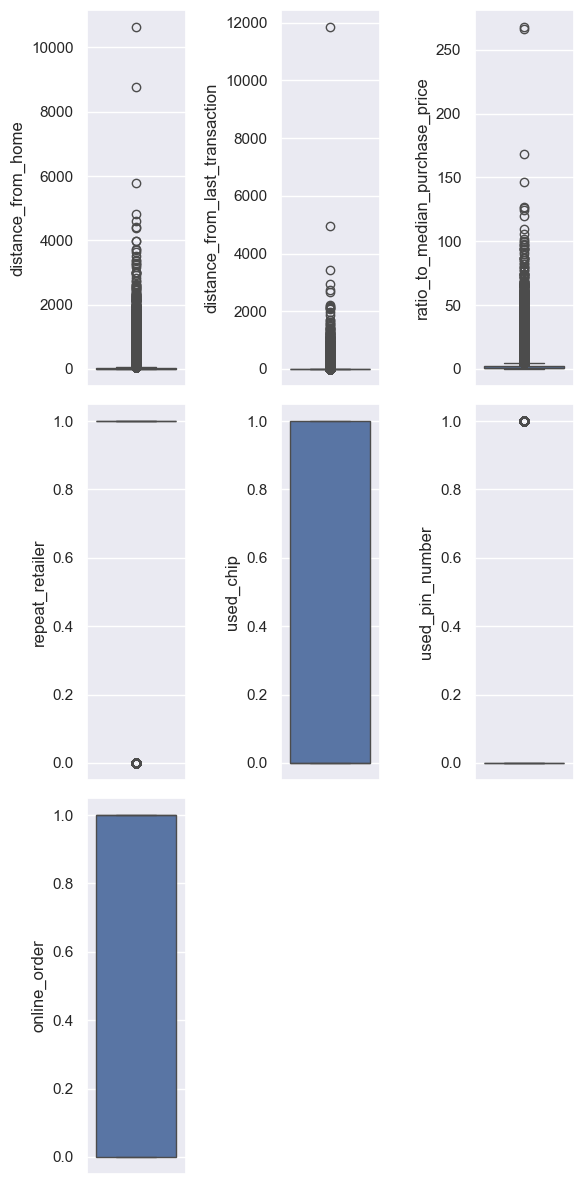

In [13]:
boxplot(
    dataset = df.drop("fraud", axis=1), 
    style   = "darkgrid", 
    height  = 12, 
    width   = 6
)

In [14]:
def plot_bar_churn_relations(df):
    """
    Generates bar charts to visualize the relationship between selected features 
    and the fraud label (`fraud`) in a transaction dataset.

    The function creates a 2x2 grid of plots using Matplotlib:
        1. Average distance from home by fraud status.
        2. Average distance from last transaction by fraud status.
        3. Ratio to median purchase price by fraud status.
        4. Proportion of binary categorical features stacked by fraud.

    Args:
        df (DataFrame): A Pandas DataFrame containing the transaction dataset. 
                        Must include the following columns: 
                        'distance_from_home', 'distance_from_last_transaction', 
                        'ratio_to_median_purchase_price', 
                        'repeat_retailer', 'used_chip', 
                        'used_pin_number', 'online_order', and 'fraud'.

    Returns:
        None: The function displays the plots directly using Matplotlib.
    """
        
    # Define o estilo do gráfico
    plt.style.use('ggplot')
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Relação entre variáveis e fraude (fraud)', fontsize=16)

    # 1. Distância média de casa por fraude
    dist_home = df.groupby('fraud')['distance_from_home'].mean()
    axs[0, 0].bar(dist_home.index.astype(str), dist_home.values, 
                  color=['skyblue', 'salmon'], edgecolor="black")
    axs[0, 0].set_title('Distância média de casa por fraude')
    axs[0, 0].set_xlabel('Fraude')
    axs[0, 0].set_ylabel('Distância média')

    # 2. Distância média da última transação por fraude
    dist_last = df.groupby('fraud')['distance_from_last_transaction'].mean()
    axs[0, 1].bar(dist_last.index.astype(str), dist_last.values, 
                  color=['skyblue', 'salmon'], edgecolor="black")
    axs[0, 1].set_title('Distância média da última transação por fraude')
    axs[0, 1].set_xlabel('Fraude')
    axs[0, 1].set_ylabel('Distância média')

    # 3. Média do ratio_to_median_purchase_price por fraude
    ratio_median = df.groupby('fraud')['ratio_to_median_purchase_price'].mean()
    axs[1, 0].bar(ratio_median.index.astype(str), ratio_median.values, 
                  color=['skyblue', 'salmon'], edgecolor="black")
    axs[1, 0].set_title('Média da razão com a mediana do valor da compra')
    axs[1, 0].set_xlabel('Fraude')
    axs[1, 0].set_ylabel('Razão média')

    # 4. Features categóricas binárias (empilhadas)
    binary_features = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
    binary_data = pd.DataFrame()

    for feature in binary_features:
        temp = pd.crosstab(df[feature], df['fraud'], normalize='index')
        binary_data = pd.concat([binary_data, temp], keys=[feature], axis=1)

    # Plotando o stacked bar para cada uma das binárias separadamente
    fig_bin, axs_bin = plt.subplots(2, 2, figsize=(15, 10))
    fig_bin.suptitle('Proporção de fraude por feature binária', fontsize=16)

    for i, feature in enumerate(binary_features):
        row, col = divmod(i, 2)
        pd.crosstab(df[feature], df['fraud'], normalize='index').plot(
            kind='bar', stacked=True, ax=axs_bin[row, col],
            color=['skyblue', 'salmon'], edgecolor="black"
        )
        axs_bin[row, col].set_title(f'{feature.replace("_", " ").title()} vs Fraude')
        axs_bin[row, col].set_ylabel('Proporção')
        axs_bin[row, col].legend(title='Fraude', labels=['Não', 'Sim'])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

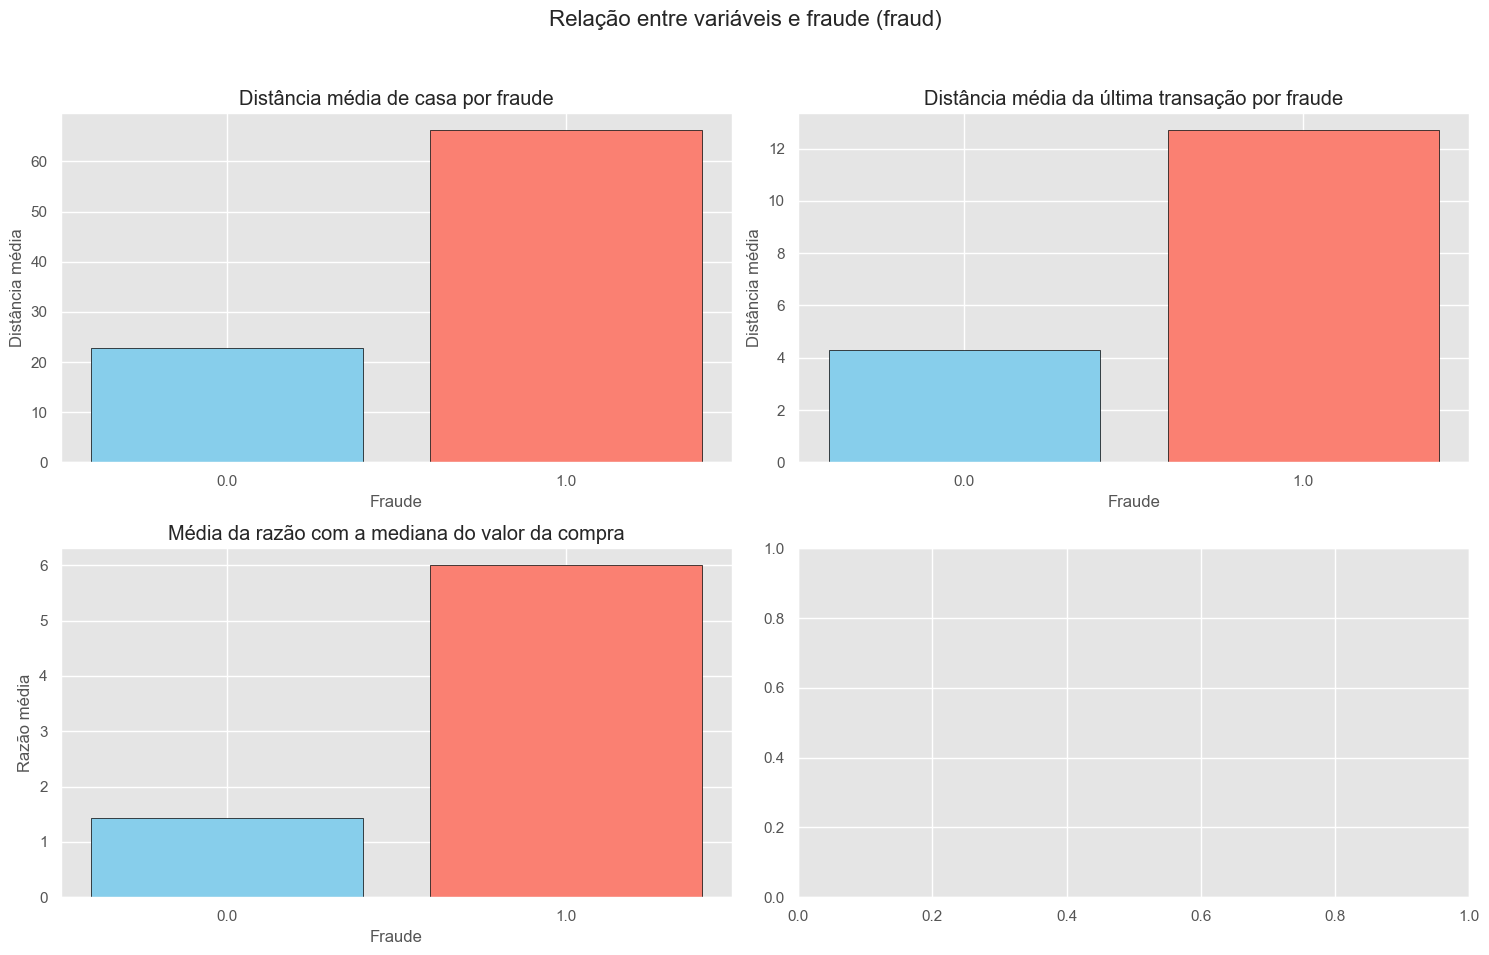

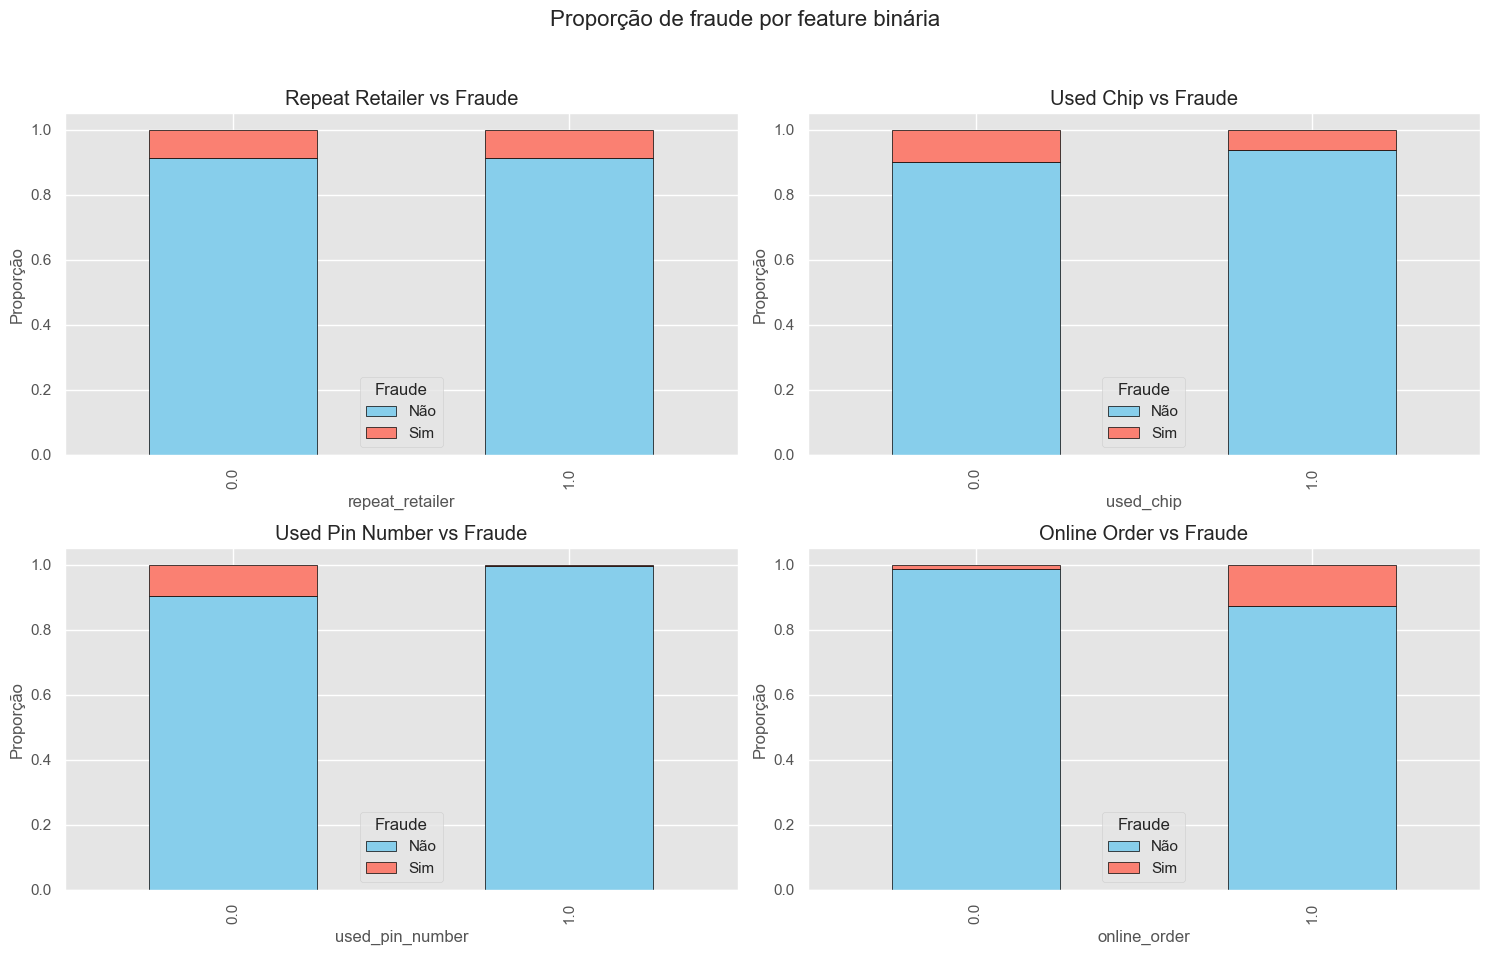

In [15]:
plot_bar_churn_relations(df=df)

Analisando os diferentes gráficos, compreende-se que em termos visuais que certas relações se verificam como demonstrado na matriz de correlação, podendo salientar a relação da distância média de casa por fraude e o used pin number, de modo que o primeiro representa uma relação positiva enquanto que o outro negativa. Tais relações identificadas poderiam ser utilizadas para o time de negócio elaborar um planejamento para considerar qual cliente poderia estr buscando fraudar o cartão em função das relações observadas. 

### Data Prep. 

Nessa parte será realizado à preparação dos dados para que possam ser informados aos algoritmos de ML. Por mais que boa parte da preparação dos dados já fora realizada, falta tratar os outliers identificados. Devido à acentuada assimetria observada, o método de tratamento será a `winsorização`, na qual substitui-se os valores tidos como outliers pelos limites superiores e inferiores da distribuição, respectivamente. 


In [16]:
def apply_winsorization(df, feature, lower_pct, upper_pct):
    """
    Applies winsorization to a given feature of the DataFrame.
    
    Args:
        df (DataFrame): Dataset containing the feature.
        feature (str): Name of the feature to winsorize.
        lower_pct (float): Proportion to cap from the lower end (e.g., 0.05 = 5%).
        upper_pct (float): Proportion to cap from the upper end.
    
    Returns:
        Series: The winsorized feature.
    """
    winsorized = winsorize(df[feature], limits=(lower_pct, upper_pct))
    return pd.Series(winsorized, index=df.index)

In [17]:
# Distance from home
df['distance_from_home'] = apply_winsorization(df, 'distance_from_home', lower_pct=0.05, upper_pct=0.01)

# Distance from last transaction
df['distance_from_last_transaction'] = apply_winsorization(df, 'distance_from_last_transaction', lower_pct=0.01, upper_pct=0.05)

# Ratio to median purchase price
df['ratio_to_median_purchase_price'] = apply_winsorization(df, 'ratio_to_median_purchase_price', lower_pct=0.01, upper_pct=0.05)

In [18]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


A estratégia de treinamento do modelo será a Hold-out. Nesse sentido, definirei um percentual de treinamento e de teste do dataset, realizando depois a normalização dos dados antes desses serem passados para os algortimos de ML. A normalização dos dados se dará em relação às variáveis contínuas - `balance`, `estimated salary` e `credit score` -, com o objetivo de colocá-las numa mesma distribuição para contribuir positivamente com a precisão dos modelos de ML. Para fins de redução a ocorrência de `data leakage`, a normalização será realizada depois da segmentação dos dados em treino e teste. 

In [19]:
SEED = 15

X = df.drop("fraud", axis=1)
y = df["fraud"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=SEED,
                                                    shuffle=True)

In [21]:
X_train.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
501062,23.766571,0.139455,0.974909,1.0,0.0,0.0,1.0
148899,38.520254,8.479968,0.961978,1.0,1.0,1.0,1.0
423795,10.478279,3.362278,3.627658,1.0,0.0,0.0,0.0
647321,8.457423,9.695160,0.192001,1.0,0.0,0.0,0.0
67783,12.052515,0.174814,2.832383,1.0,0.0,0.0,1.0


In [22]:
scaler = StandardScaler()

features_to_normalize = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']
normalized_values = scaler.fit_transform(X_train[features_to_normalize])

X_train_normalized = pd.DataFrame(
    normalized_values,
    columns = features_to_normalize,
    index   = X_train.index # preserva o índice original
)

X_train_rest = X_train.drop(columns=features_to_normalize)
X_train = pd.concat([X_train_normalized, X_train_rest], axis=1)

X_train.head()


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
501062,-0.019042,-0.609406,-0.390016,1.0,0.0,0.0,1.0
148899,0.341287,1.069286,-0.398144,1.0,1.0,1.0,1.0
423795,-0.343581,0.039250,1.277240,1.0,0.0,0.0,0.0
647321,-0.392937,1.313867,-0.882075,1.0,0.0,0.0,0.0
67783,-0.305134,-0.602289,0.777409,1.0,0.0,0.0,1.0


In [23]:
y_train.head()

501062    0.0
148899    0.0
423795    0.0
647321    0.0
67783     0.0
Name: fraud, dtype: float64

In [24]:
scaler = StandardScaler()

features_to_normalize = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']
normalized_values = scaler.fit_transform(X_test[features_to_normalize])

X_test_normalized = pd.DataFrame(
    normalized_values,
    columns = features_to_normalize,
    index   = X_test.index # preserva o índice original
)

X_test_rest = X_test.drop(columns=features_to_normalize)
X_test = pd.concat([X_test_normalized, X_test_rest], axis=1)

X_test.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
27924,-0.437584,-0.579001,-0.581384,1.0,0.0,0.0,1.0
432317,0.680882,-0.621384,-0.751401,1.0,1.0,0.0,0.0
379667,-0.494867,-0.533769,0.811073,1.0,0.0,0.0,1.0
668408,-0.529869,-0.619724,0.151898,1.0,0.0,0.0,1.0
546927,-0.574293,-0.610099,1.739871,0.0,1.0,0.0,1.0


In [25]:
y_test.head()

27924     0.0
432317    0.0
379667    0.0
668408    0.0
546927    1.0
Name: fraud, dtype: float64

### Random Forest

In [ ]:
ranfom_forest = RandomForestClassifier(
    n_estimators      = 150, 
    criterion         = "gini", 
    max_depth         = 10, 
    class_weight      = "balanced", 
    min_samples_split = 10, 
    min_samples_leaf  = 2, 
    random_state      = SEED
)

ranfom_forest.fit(X_train, y_train)

### Logistic Regression 

In [ ]:
precision =  make_scorer(precision_score)
recall =  make_scorer(recall_score)
f1_score = make_scorer(f1_score)

print(f"Precisão: {round(precision, 2)}\nRecall: {round(recall, 2)}\n F1-score {round(f1_score, 2)}")

In [ ]:
rg_log = LogisticRegression(
    C            = "1e-2", 
    penalty      = "l1", 
    solver       = "saga", 
    class_weight = "balanced", 
    max_iter     = 1000, 
    random_state = SEED
)

### Analisando as métricas do Random Forest

In [ ]:
importances = ranfom_forest.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

In [ ]:
confusion_metrix = confusion_matrix(y_test, ranfom_forest.predict(X_test))

sns.heatmap(confusion_metrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, ranfom_forest.predict(X_test))
roc_auc = auc(fpr, tpr)

# Plotar a curva ROC

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()

### Analisando as métricas para a Regressão Logística

In [ ]:
precision_rg_loss =  make_scorer(precision_score)
recall_rg_loss =  make_scorer(recall_score)
f1_score_rg_loss = make_scorer(f1_score)

print(f"Precisão: {round(precision_rg_loss, 2)}\nRecall: {round(recall_rg_loss, 2)}\n F1-score {round(f1_score_rg_loss, 2)}")

In [ ]:
confusion_metrix_rg = confusion_matrix(y_test, rg_log.predict(X_test))

sns.heatmap(confusion_metrix_rg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, rg_log.predict(X_test))
roc_auc = auc(fpr, tpr)

# Plotar a curva ROC

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Regression Logistic')
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()